In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from myModeler_v2 import myModel
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset
import math

In [2]:
print(torch.cuda.is_available())

#from google.colab import drive
#drive.mount('/content/drive')


# Veri setini (MNIST - El yazısı rakamlar) indiriyoruz ve normalize ediyoruz
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_and_validation_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)


test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

num_train = len(train_and_validation_dataset) # 50000
indices = list(range(num_train))
split = 5000 # Validation için ayrılacak miktar

# İndeksleri karıştır (Shuffle)
np.random.seed(42) # Her seferinde aynı bölünme olması için
np.random.shuffle(indices)

train_idx, val_idx = indices[split:], indices[:split]

# Subset'leri oluştur
train_subset = Subset(train_and_validation_dataset, train_idx)
val_subset = Subset(train_and_validation_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)



True
Files already downloaded and verified


c:\Users\Ataka\miniconda3\envs\ai_dev\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:

model = myModel()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Toplam Parametre: {total_params}")
print(f"Eğitilebilir Parametre: {trainable_params}")

# 1. GPU kullanılabilir mi kontrol et
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

# 2. Modelin nerede olduğuna bak
# model.parameters() içindeki ilk ağırlığın cihazına bakarız
print(f"Model şu an şurada: {next(model.parameters()).device}")

model.to(device)

# 2. Modelin nerede olduğuna bak
# model.parameters() içindeki ilk ağırlığın cihazına bakarız
print(f"Model şu an şurada: {next(model.parameters()).device}")

# criterion
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

criterion.to(device)

Toplam Parametre: 364618
Eğitilebilir Parametre: 364618
Kullanılan cihaz: cuda
Model şu an şurada: cpu
Model şu an şurada: cuda:0


CrossEntropyLoss()

In [4]:
epochs = 30 # Verinin üzerinden kaç kez geçileceği
gradients = [[],[],[],[],[]]
train_losses=[]
val_losses=[]
val_accuracies=[]

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # 1. Gradyanları sıfırla
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # 2. Forward pass: Tahmin yap
        outputs = model(images)

        # 3. Kaybı (hata oranını) hesapla
        loss = criterion(outputs, labels)

        # 4. Backward pass: Hatayı geriye yay ve ağırlıkları güncelle
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        

    #print(f"Epoch {epoch+1} - Kayıp: {running_loss/len(train_loader)}")

    counter = 0
    for name, param in model.named_parameters():
        if param.grad is not None and counter < 10:
            #print(f"{name} gradient mean: {param.grad.abs().mean().item()}")
            if counter %2 ==0:  
                gradients[math.floor(counter/2)].append(param.grad.abs().mean().item())
            counter += 1

    # --- DOĞRULAMA (VALIDATION) AŞAMASI ---
    model.eval() # Modeli değerlendirme moduna al (Dropout ve BatchNorm pasif)
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # Gradyan hesaplamayı kapat (Hafıza tasarrufu ve hız sağlar)
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            # Accuracy hesaplama
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Epoch sonu ortalama değerleri hesapla
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: %{val_acc:.2f}')

print("Eğitim Tamamlandı!")

Epoch [1/30], Train Loss: 1.4382, Val Loss: 1.1072, Val Acc: %61.08
Epoch [2/30], Train Loss: 1.0768, Val Loss: 0.9632, Val Acc: %66.18
Epoch [3/30], Train Loss: 0.9374, Val Loss: 0.8648, Val Acc: %69.76
Epoch [4/30], Train Loss: 0.8530, Val Loss: 0.8104, Val Acc: %72.12
Epoch [5/30], Train Loss: 0.7888, Val Loss: 0.8586, Val Acc: %70.60
Epoch [6/30], Train Loss: 0.7385, Val Loss: 0.7497, Val Acc: %74.08
Epoch [7/30], Train Loss: 0.7009, Val Loss: 0.7758, Val Acc: %73.96
Epoch [8/30], Train Loss: 0.6671, Val Loss: 0.6631, Val Acc: %77.54
Epoch [9/30], Train Loss: 0.6303, Val Loss: 0.7061, Val Acc: %75.84
Epoch [10/30], Train Loss: 0.5983, Val Loss: 0.7517, Val Acc: %75.08
Epoch [11/30], Train Loss: 0.5826, Val Loss: 0.7202, Val Acc: %76.10
Epoch [12/30], Train Loss: 0.5518, Val Loss: 0.6844, Val Acc: %77.50
Epoch [13/30], Train Loss: 0.5238, Val Loss: 0.6600, Val Acc: %78.04
Epoch [14/30], Train Loss: 0.5133, Val Loss: 0.6879, Val Acc: %77.26
Epoch [15/30], Train Loss: 0.4910, Val Loss

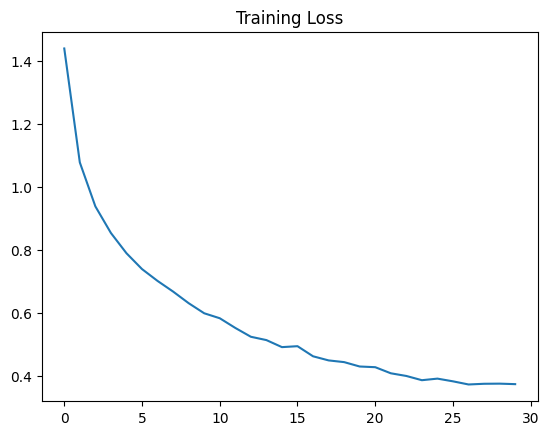

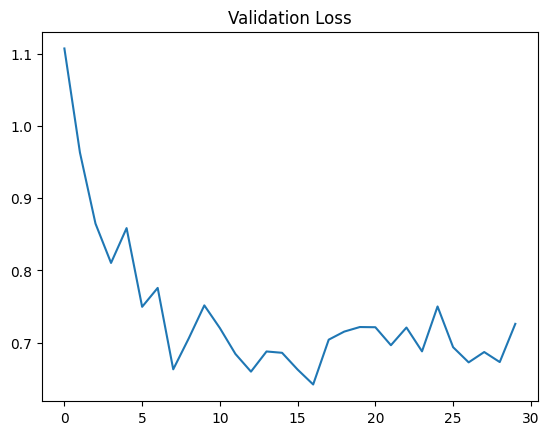

In [5]:
"""plt.figure(figsize=(8, 20)) # Boyutu dikeyde uzun tutuyoruz

plt.subplot(5, 1, 1) # 5 satır, 1 sütun, 1. grafik
plt.plot(np.arange(len(gradients[0])),gradients[0])
plt.title(list(model.named_parameters())[0][0])

plt.subplot(5, 1, 2) # 5 satır, 1 sütun, 2. grafik
plt.plot(np.arange(len(gradients[1])),gradients[1])
plt.title(list(model.named_parameters())[2][0])

plt.subplot(5, 1, 3) # 5 satır, 1 sütun, 3. grafik
plt.plot(np.arange(len(gradients[2])),gradients[2])
plt.title(list(model.named_parameters())[4][0])

plt.subplot(5, 1, 4) # 5 satır, 1 sütun, 4. grafik
plt.plot(np.arange(len(gradients[3])),gradients[3])
plt.title(list(model.named_parameters())[6][0])

plt.subplot(5, 1, 5) # 5 satır, 1 sütun, 5. grafik
plt.plot(np.arange(len(gradients[4])),gradients[4])
plt.title(list(model.named_parameters())[8][0])
plt.legend()
plt.show()"""


plt.plot(train_losses)
plt.title('Training Loss')
plt.show()


plt.plot(val_losses)
plt.title('Validation Loss')
plt.show()


In [6]:
from modulefinder import test
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval()  # Modeli değerlendirme moduna al (dropout vb. varsa kapatır)

    with torch.no_grad(): # Gradyan hesaplamayı kapat (hafıza tasarrufu sağlar)
        for x, y in loader:
            # Tahmin yap
            x, y = x.to(device), y.to(device)
            scores = model(x)
            _, predictions = scores.max(1) # En yüksek skorlu sınıfı seç

            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train() # Modeli tekrar eğitim moduna döndür
    return float(num_correct) / num_samples * 100

# Kullanımı:
print(f"Test Başarımı: %{check_accuracy(test_loader, model):.2f}")


Test Başarımı: %77.68


In [7]:
# Modelinizin isminin 'SimpleModel' olduğunu varsayalım
# Kaydedilecek dosya yolunu belirleyin (Drive'a bağlıysanız orayı kullanın)
model_path = "myModel_v2.pth"

# Model ağırlıklarını kaydetme
torch.save(model.state_dict(), model_path)
print(f"Model başarıyla şuraya kaydedildi: {model_path}")



# modeli görselleştir.
model.eval()
#model.train()
dummy_input = torch.randn(1, 3, 32, 32).to(device)

onnx_name = "myModel_v2.onnx"

torch.onnx.export(
    model,                      # Eğitilen model
    dummy_input,                # Örnek girdi
    onnx_name,             # Kaydedilecek dosya adı
    export_params=True,         # Eğitilmiş ağırlıkları da içine ekle
    opset_version=11,           # Standart operasyon seti sürümü
    do_constant_folding=True,   # Gereksiz işlemleri optimize et (sadeleştir)
    input_names=['input'],      # Girdi katmanının adı (opsiyonel)
    output_names=['output'],    # Çıktı katmanının adı (opsiyonel)
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}} # Farklı batch size'lara izin ver
)

print(f"Model başarıyla {onnx_name} olarak kaydedildi!")

Model başarıyla şuraya kaydedildi: myModel_v2.pth
Model başarıyla myModel_v2.onnx olarak kaydedildi!
